# Study Mergers and so on

In [3]:
import h5py
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import os
import struct
from scipy.optimize import curve_fit
import time
import illustris_python as il
import astropy


In [4]:
import sys
sys.path.append('/home/tnguser/TNGCluster')

from astro_utils.function_coord import *
from astro_utils.function_plot import *
from astro_utils.spherical_coord import *
from astro_utils.utils_astro import *
from astro_utils.IllustrisTNG_functions.Get_Particles_snap import *
from astro_utils.IllustrisTNG_functions.function_illustris import *

from astropy.cosmology import FlatLambdaCDM, z_at_value
from astropy import units  as u
from scipy.stats import binned_statistic
from collections import OrderedDict

# Get the Tables of Satellites that are close to target 

In [ ]:
import illustris_python as il
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
basePath = '../sims.TNG/TNG50-1/output'
base_out = '/home/tnguser/output/'   
basePath_tng50 = '/home/tnguser/sims.TNG/TNG50-1/output'

snap_number =99

Header = il.groupcat.loadHeader(basePath_tng50, snap_number)
aexp = Header['Time'][()]

############## id of halo ##################
#idsub=[476266,533590,584875,593480,596400,631558]
idsub=[649627,656142]

for index_id in idsub:
    subhalos_tng50 = il.groupcat.loadSingle(basePath_tng50,snap_number,subhaloID=index_id)#,fields=['SubhaloGrNr','SubhaloMass','SubhaloPos'])
    SubhaloPos = np.array(subhalos_tng50['SubhaloPos'])
    SubhaloGrNr = np.array(subhalos_tng50['SubhaloGrNr'])

    halos99_tng50 = il.groupcat.loadSingle(basePath_tng50,snap_number,haloID=SubhaloGrNr)#,fields=['Group_R_Crit200','Group_M_Crit200','GroupPos'])
    Group_R_Crit200_tng50 =  np.array(halos99_tng50['Group_R_Crit200'])

    rvirFoF = Group_R_Crit200_tng50
    rvirFoF*= aexp
    ############## subgroup ################
    fields = ['SubhaloMass','SubhaloCM']
    subhalos = il.groupcat.loadSubhalos(basePath_tng50, snap_number, fields=fields)

    count = subhalos['count']
    CM = subhalos['SubhaloCM']
    mass = subhalos['SubhaloMass']* 1e10 / 0.6774
    nsub=len(mass)

    index=np.where(np.sqrt(np.sum((CM-SubhaloPos)**2, axis = 1))<2*rvirFoF)

    nsub=len(index[0])
    pos200Sel =np.zeros((nsub,5), dtype=np.float)


    pos200Sel[:,0] = index[0]
    pos200Sel[:,1] = mass[index]
    pos200Sel[:,2] = CM[index,0]
    pos200Sel[:,3] = CM[index,1]
    pos200Sel[:,4] = CM[index,2]
    fig, ax = plt.subplots(1,1,figsize=(5,5),subplot_kw={"projection":'3d'})
    ax.scatter(CM[index,0],CM[index,1],CM[index,2],color='k')   
    plt.show()   
    
    
    variable = pos200Sel[:,1]/np.sum((CM[index]-SubhaloPos)**2, axis = 1)
    variable_sort = variable[variable.argsort()][::-1]
    
    subhalos = pos200Sel[:,0]   
    subhalos_sort = subhalos[variable.argsort()][::-1]
    
    print(variable_sort[0:10],subhalos_sort[0:10])
    
    dumpfile = base_out + 'Transfer/Satellite_2Rvir_'+ str(index_id)     
    data_file_path =dumpfile             
    np.savez(data_file_path,G_r=variable_sort,subhalos=subhalos_sort)
        


# Follow their path back in time

Warning, empty return. Subhalo [476280] at snapNum [99] not in tree.
An exception occurred
An exception occurred
Warning, empty return. Subhalo [476275] at snapNum [99] not in tree.
An exception occurred
An exception occurred
Warning, empty return. Subhalo [533603] at snapNum [99] not in tree.
An exception occurred
Warning, empty return. Subhalo [593485] at snapNum [99] not in tree.
An exception occurred


/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:152: RuntimeWarning: invalid value encountered in true_divide
/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:153: RuntimeWarning: invalid value encountered in true_divide


An exception occurred
An exception occurred


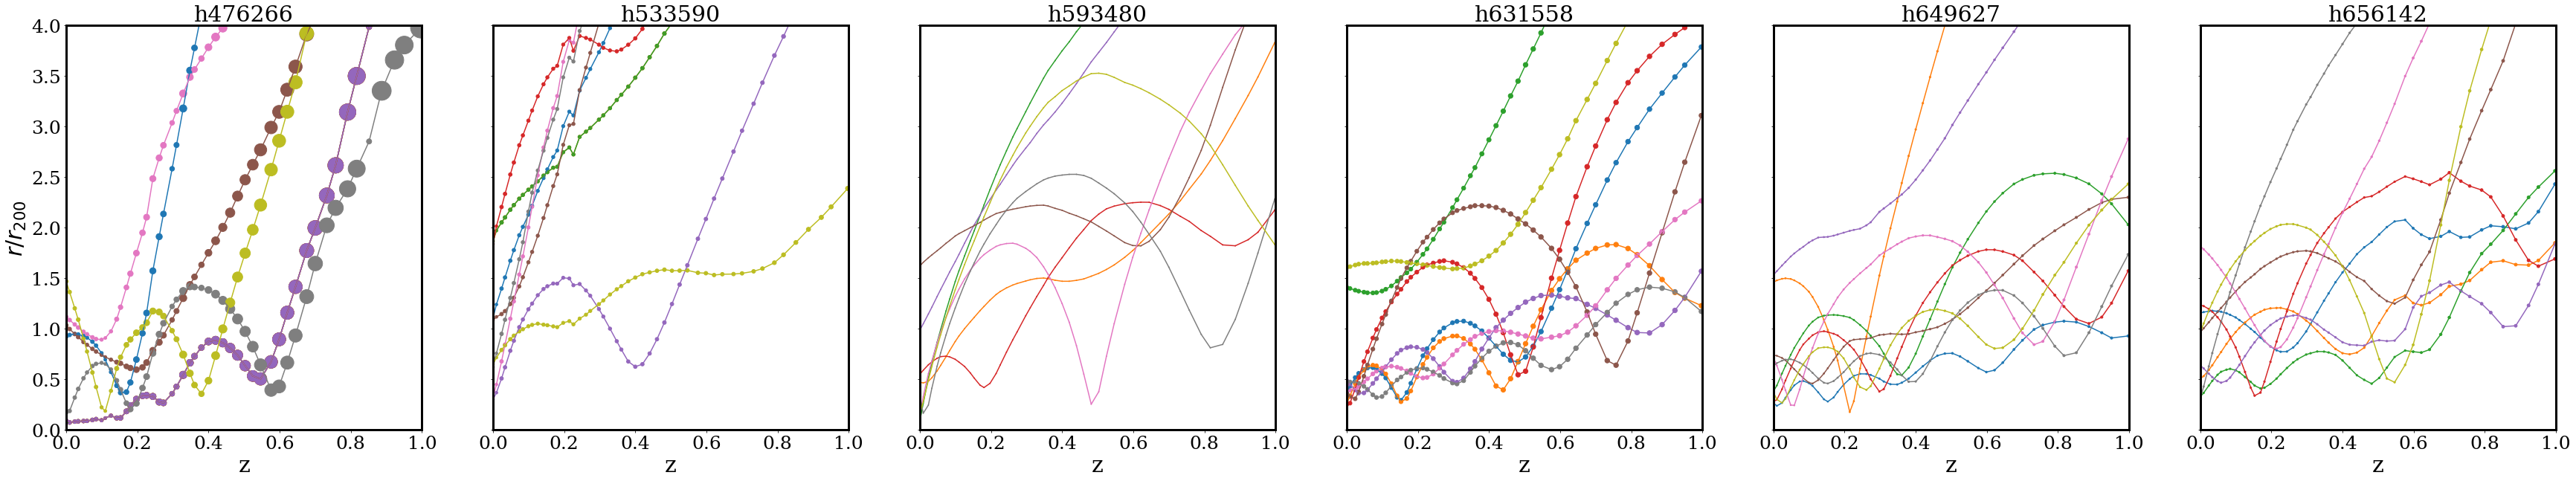

In [12]:
# import illustris_python as il
import numpy as np
from matplotlib import pyplot as plt
from collections import OrderedDict

basePath = '../sims.TNG/TNG50-1/output'
base_out = '/home/tnguser/output/'   
basePath_tng50 = '/home/tnguser/sims.TNG/TNG50-1/output'

plt.rcParams['axes.linewidth'] = 3
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['xtick.labelsize'] = 25
plt.rcParams['ytick.labelsize'] = 25

fig, ax = plt.subplots(1,6, figsize=(60,10), sharey=True)
axli = ax.flatten()
#idsub=[476266,533590,593480,631558,649627,656142]
idsub=[649627,656142]

######################################

data = np.load(base_out+"snap_vs_z.npz")

snap_selected = data['snaparr']
z_selected = data['zselected']
aexp_selected = data['aexselected']

######################################
snap_lista= []
ngal=10
z_wanted = np.linspace(0,2,ngal)    
z_wanted = list(z_wanted)

############# first redshift ###########
idxfirst = find_nearest(z_wanted[0], z_selected)
first_snap  = int(snap_selected[idxfirst])
########### last redshift ##############
idxlast = find_nearest(z_wanted[ngal-1], z_selected)    
last_snap  = int(snap_selected[idxlast])
########################################
snap_lista = list(np.arange(last_snap,first_snap+1)[::-1])
snap_lista = list(OrderedDict.fromkeys(snap_lista))
       
############## id of halo ##################
for j,index_id in enumerate(idsub):
    
    axli[j].set_title("h"+str(index_id), fontsize=30)
    axli[0].set_ylabel(r'$r/r_{200}$', fontsize=30)      
    axli[j].set_xlabel('z', fontsize=30)     
    axli[j].set_ylim(0.0, 4,0)
    axli[j].set_xlim(0.0, 1,0)

    ################### list of sat ############
    dumpfile = base_out + 'Transfer/Satellite_2Rvir_'+str(index_id)+'.npz'
    data = np.load(dumpfile)    
    subhalos = data['subhalos']
    G_r = data['G_r']
    subhalos= subhalos.astype(int)
    ############################################
    fields = ['SubhaloMass','SubfindID','SnapNum']
    
    tree = il.sublink.loadTree(basePath_tng50, 99, index_id, fields=fields, onlyMPB=True)
    SnapTree = tree['SnapNum']
    SubfindIDTree = tree['SubfindID']
    SubhaloMass_index_id = tree['SubhaloMass']
    
    a = SnapTree
    b = set(snap_lista)
    c =[i for i, item in enumerate(a) if item in b]

    subfind_cent = SubfindIDTree[c]
    
    SubhaloPos_sat_x=np.zeros(len(snap_lista)) 
    SubhaloPos_sat_y=np.zeros(len(snap_lista)) 
    SubhaloPos_sat_z=np.zeros(len(snap_lista)) 

    SubhaloPos_obl_x=np.zeros(len(snap_lista)) 
    SubhaloPos_obl_y=np.zeros(len(snap_lista)) 
    SubhaloPos_obl_z=np.zeros(len(snap_lista))     
    s_linear_arr=np.zeros(len(snap_lista)) 
    z_arr=np.zeros(len(snap_lista)) 
    R200_arr=np.zeros(len(snap_lista)) 

    for index_sat in subhalos[1:10]:
        
        fields = ['SubhaloMass','SubfindID','SnapNum']
               
        tree = il.sublink.loadTree(basePath_tng50, 99, index_sat, fields=fields, onlyMPB=True)
        
        try:
            SnapTree = tree['SnapNum']
            SubfindIDTree = tree['SubfindID']
            SatMass = tree['SubhaloMass']
            
            #if (SatMass[0]>(SubhaloMass_index_id[0]/10)):

            a = SnapTree
            b = set(snap_lista)
            c =[i for i, item in enumerate(a) if item in b]

            subfind_number = SubfindIDTree[c]
            ############ FoF and Subfind ###########
            for m,snap_number in enumerate(snap_lista):
                Header = il.groupcat.loadHeader(basePath_tng50, snap_number)

                redsh = Header['Redshift'][()]
                aexp = Header['Time'][()]
                hh = Header['HubbleParam'][()]
                Omega0 = Header['Omega0'][()]
                OmegaLambda = Header['OmegaLambda'][()]
                Omega = Omega0+OmegaLambda
                OmegaR = 0


                subhalos_tng50 = il.groupcat.loadSingle(basePath_tng50,snap_number,subhaloID=subfind_cent[m])
                SubhaloPos_obl = np.array(subhalos_tng50['SubhaloPos'])
                SubhaloMass = np.array(subhalos_tng50['SubhaloMass'])    
                SubhaloGrNr = np.array(subhalos_tng50['SubhaloGrNr'])    

                SubhaloPos_obl_x[m]=SubhaloPos_obl[0]
                SubhaloPos_obl_y[m]=SubhaloPos_obl[1]
                SubhaloPos_obl_z[m]=SubhaloPos_obl[2]


                halos99_tng50 = il.groupcat.loadSingle(basePath_tng50,snap_number,haloID=SubhaloGrNr)
                Group_R_Crit200_tng50 =  np.array(halos99_tng50['Group_R_Crit200'])
                rvirFoF = Group_R_Crit200_tng50
                rvirFoF*= aexp
                R200_arr[m]=rvirFoF 
                ############## sattelite ################

                s_main = (SubhaloMass)

                subhalos_tng50 = il.groupcat.loadSingle(basePath_tng50,snap_number,subhaloID=subfind_number[m])
                SubhaloPos = np.array(subhalos_tng50['SubhaloPos'])
                SubhaloMass = np.array(subhalos_tng50['SubhaloMass'])
                SubhaloPos_sat_x[m]=SubhaloPos[0]
                SubhaloPos_sat_y[m]=SubhaloPos[1]
                SubhaloPos_sat_z[m]=SubhaloPos[2]

                s_linear = (SubhaloMass/s_main)*5e3
                s_linear_arr[m]=s_linear 
                z_arr[m]=redsh

        
        except:            
          print("An exception occurred")        


        axli[j].scatter(z_arr,np.sqrt((SubhaloPos_sat_x-SubhaloPos_obl_x)**2+(SubhaloPos_sat_y-SubhaloPos_obl_y)**2+(SubhaloPos_sat_z-SubhaloPos_obl_z)**2)/R200_arr,s=s_linear_arr)   
        axli[j].plot(z_arr,np.sqrt((SubhaloPos_sat_x-SubhaloPos_obl_x)**2+(SubhaloPos_sat_y-SubhaloPos_obl_y)**2+(SubhaloPos_sat_z-SubhaloPos_obl_z)**2)/R200_arr)   

plt.savefig(base_out + 'Transfer/Transit_Sat.png' , bbox_inches='tight', dpi=150) 
        
plt.show()   


Warning, empty return. Subhalo [593485] at snapNum [99] not in tree.
An exception occurred
An exception occurred


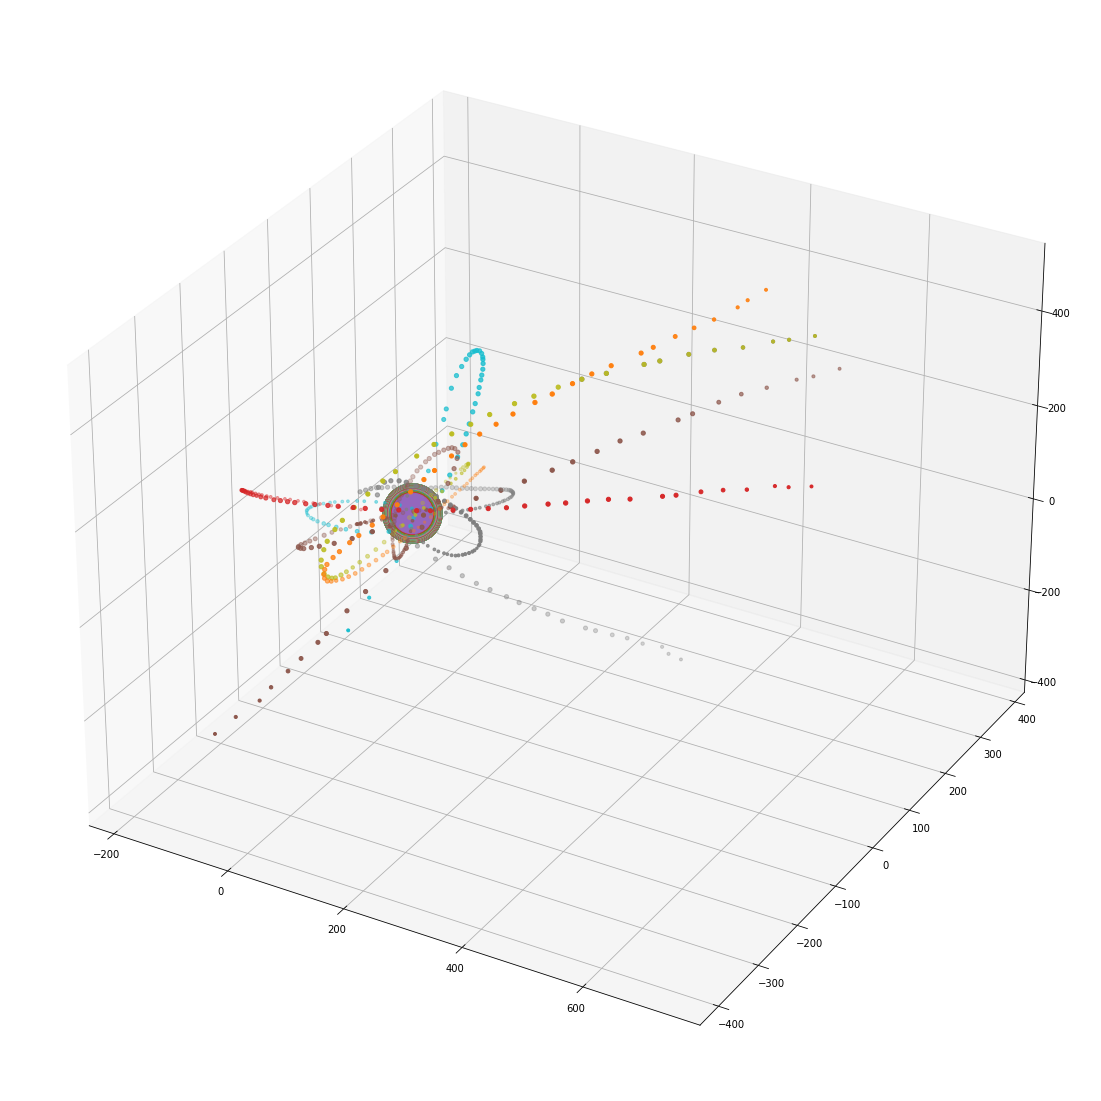

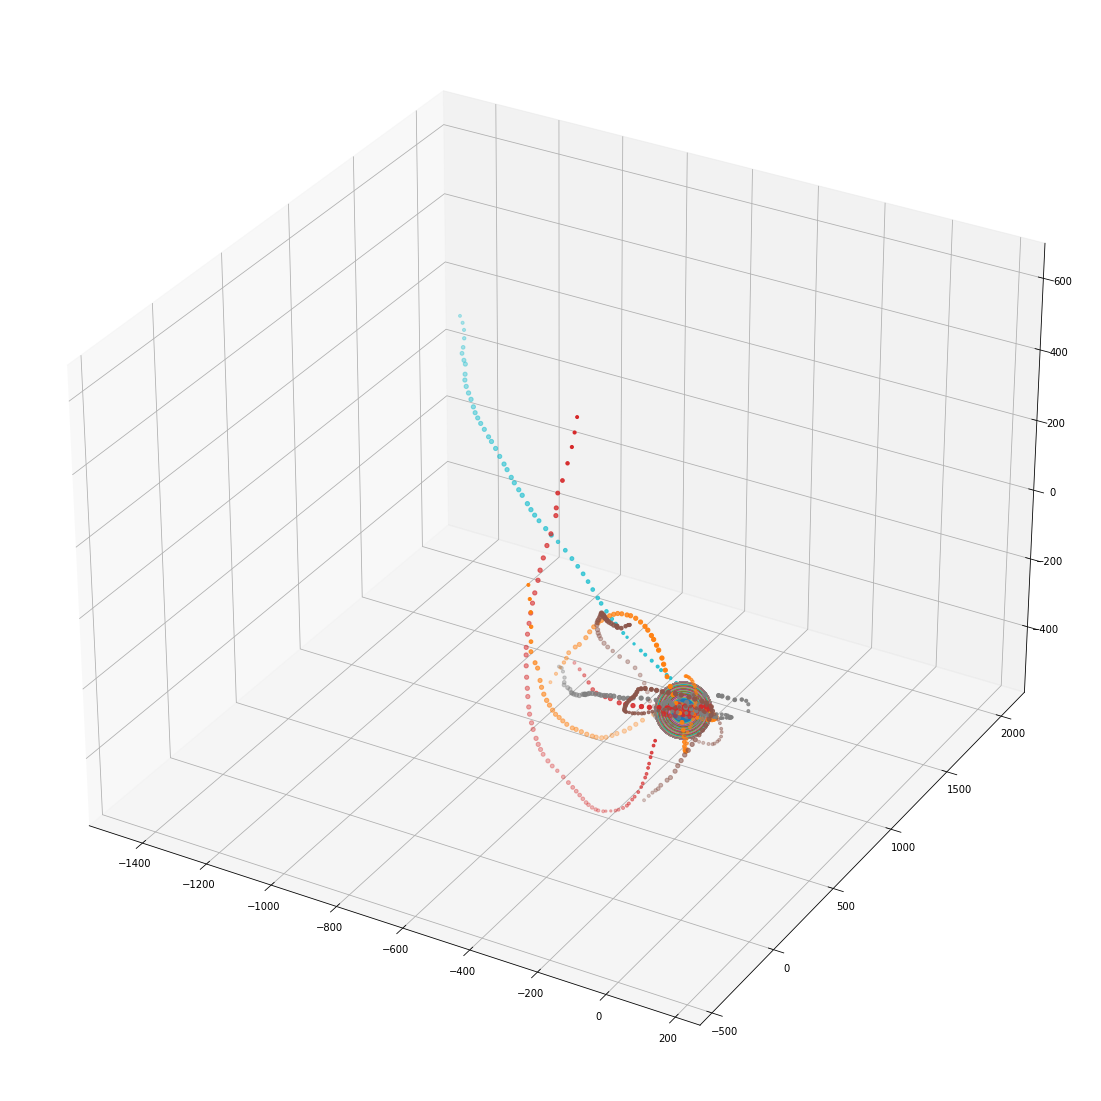

In [7]:
# import illustris_python as il
import numpy as np
from matplotlib import pyplot as plt
from collections import OrderedDict

basePath = '../sims.TNG/TNG50-1/output'
base_out = '/home/tnguser/output/'   
basePath_tng50 = '/home/tnguser/sims.TNG/TNG50-1/output'


idsub=[593480,584875]


data = np.load(base_out+"snap_vs_z.npz")

snap_selected = data['snaparr']
z_selected = data['zselected']
aexp_selected = data['aexselected']

######################################
snap_lista= []
ngal=10
z_wanted = np.linspace(0,2,ngal)    
z_wanted = list(z_wanted)

############# first redshift ###########
idxfirst = find_nearest(z_wanted[0], z_selected)
first_snap  = int(snap_selected[idxfirst])
########### last redshift ##############
idxlast = find_nearest(z_wanted[ngal-1], z_selected)    
last_snap  = int(snap_selected[idxlast])
########################################
snap_lista = list(np.arange(last_snap,first_snap+1)[::-1])
snap_lista = list(OrderedDict.fromkeys(snap_lista))
       


s_linear_arr=np.zeros(len(snap_lista)) 
############## id of halo ##################
for index_id in idsub:
    fig, ax = plt.subplots(1,1,figsize=(20,20),subplot_kw={"projection":'3d'})

    ################### list of sat ############
    dumpfile = base_out + 'Transfer/Satellite_2Rvir_'+str(index_id)+'.npz'
    data = np.load(dumpfile)    
    subhalos = data['subhalos']
    G_r = data['G_r']
    subhalos= subhalos.astype(int)
    ############################################
    fields = ['SubhaloMass','SubfindID','SnapNum']
    
    tree = il.sublink.loadTree(basePath_tng50, 99, index_id, fields=fields, onlyMPB=True)
    SnapTree = tree['SnapNum']
    SubfindIDTree = tree['SubfindID']

    a = SnapTree
    b = set(snap_lista)
    c =[i for i, item in enumerate(a) if item in b]

    subfind_cent = SubfindIDTree[c]
    
    SubhaloPos_sat_x=np.zeros(len(snap_lista)) 
    SubhaloPos_sat_y=np.zeros(len(snap_lista)) 
    SubhaloPos_sat_z=np.zeros(len(snap_lista)) 

    SubhaloPos_obl_x=np.zeros(len(snap_lista)) 
    SubhaloPos_obl_y=np.zeros(len(snap_lista)) 
    SubhaloPos_obl_z=np.zeros(len(snap_lista))     
    
    for index_sat in subhalos[1:10]:
        
        fields = ['SubhaloMass','SubfindID','SnapNum']
               
        tree = il.sublink.loadTree(basePath_tng50, 99, index_sat, fields=fields, onlyMPB=True)
        
        try:
            SnapTree = tree['SnapNum']
            SubfindIDTree = tree['SubfindID']

            a = SnapTree
            b = set(snap_lista)
            c =[i for i, item in enumerate(a) if item in b]

            subfind_number = SubfindIDTree[c]
            ############ FoF and Subfind ###########
            for m,snap_number in enumerate(snap_lista):
                Header = il.groupcat.loadHeader(basePath_tng50, snap_number)

                redsh = Header['Redshift'][()]
                aexp = Header['Time'][()]
                hh = Header['HubbleParam'][()]
                Omega0 = Header['Omega0'][()]
                OmegaLambda = Header['OmegaLambda'][()]
                Omega = Omega0+OmegaLambda
                OmegaR = 0


                subhalos_tng50 = il.groupcat.loadSingle(basePath_tng50,snap_number,subhaloID=subfind_cent[m])#,fields=['SubhaloGrNr','SubhaloMass','SubhaloPos'])
                SubhaloPos_obl = np.array(subhalos_tng50['SubhaloPos'])
                SubhaloMass = np.array(subhalos_tng50['SubhaloMass'])    
                SubhaloPos_obl_x[m]=SubhaloPos_obl[0]
                SubhaloPos_obl_y[m]=SubhaloPos_obl[1]
                SubhaloPos_obl_z[m]=SubhaloPos_obl[2]


                ############## sattelite ################

                s_linear = (SubhaloMass)*1e2 

                ax.scatter(0,0,0,s=s_linear)   

                subhalos_tng50 = il.groupcat.loadSingle(basePath_tng50,snap_number,subhaloID=subfind_number[m])#,fields=['SubhaloGrNr','SubhaloMass','SubhaloPos'])
                SubhaloPos = np.array(subhalos_tng50['SubhaloPos'])
                SubhaloMass = np.array(subhalos_tng50['SubhaloMass'])
                SubhaloPos_sat_x[m]=SubhaloPos[0]
                SubhaloPos_sat_y[m]=SubhaloPos[1]
                SubhaloPos_sat_z[m]=SubhaloPos[2]

                s_linear = (SubhaloMass)*1e2
                s_linear_arr[m]=s_linear            
        except:            
          print("An exception occurred")        


        ax.scatter(SubhaloPos_sat_x-SubhaloPos_obl_x,SubhaloPos_sat_y-SubhaloPos_obl_y,SubhaloPos_sat_z-SubhaloPos_obl_z,s=s_linear_arr)   
plt.show()   
